<h1 align="center"> Projeto 4 </h1>
<center><h3> Álgebra Linear Numérica </h3></center>
<p align="center"> Participantes: Pedro Ricardo Alves e Elainne Rohs </p>

### Questão 1. Cálculo dos refletores

#### Letra a)

-------------------------------------------

#### Letra b)

----------------------------

#### Letra c)

In [1]:
using LinearAlgebra

function reflector(x)
    T = eltype(x)

    nx = norm(x)

    # caso degenerado
    if nx == zero(T)
        return zeros(T, length(x)), zero(T)
    end

    v = copy(x)
    v[1] -= nx

    y2 = sum(abs2, x[2:end])

    if x[1] > zero(T)

        # fórmula estável para v1
        v[1] = -y2 / (nx + x[1])

        beta = (nx + x[1])/(nx*y2)
    else

        v[1] = x[1] - nx

        beta = inv(nx * (nx - x[1]))
    end

    return v, beta
end


function apply_reflector(v, beta, x)
    x - beta * v * dot(v, x)
end

apply_reflector (generic function with 1 method)

-----------------------------------

#### Letra d)

-------------------------------------------

#### Letra e)

In [2]:
function test_reflector()

    println("---------------")
    println("TESTE FLOAT64")
    println("---------------")

    x64 = Float64[1.0, 1e-8, 1e-8]

    v64, beta64 = reflector(x64)

    qx64 = apply_reflector(v64, beta64, x64)

    println("v = ", v64)
    println("beta = ", beta64)
    println("Qx = ", qx64)

    println()
    println("---------------")
    println("TESTE FLOAT32")
    println("---------------")

    x32 = Float32[1.0f0, 1e-8f0, 1e-8f0]

    v32, beta32 = reflector(x32)

    qx32 = apply_reflector(v32, beta32, x32)

    println("v = ", v32)
    println("beta = ", beta32)
    println("Qx = ", qx32)
end

test_reflector (generic function with 1 method)

----------------------------------

#### Letra f)

In [3]:
function beta_from_v(v)

    vv = dot(v,v)

    if vv == zero(eltype(v))
        return zero(eltype(v))
    end

    return 2 / vv
end

beta_from_v (generic function with 1 method)

In [4]:
function compare_beta()

    println("====== Float64 ======")

    x = Float64[1.0,1e-8,1e-8]

    v,beta1 = reflector(x)

    beta2 = beta_from_v(v)

    println("beta via x = ", beta1)
    println("beta via v = ", beta2)
    println("erro = ", abs(beta1-beta2))

    println()

    println("====== Float32 ======")

    x = Float32[1.0f0,1e-8f0,1e-8f0]

    v,beta1 = reflector(x)

    beta2 = beta_from_v(v)

    println("beta via x = ", beta1)
    println("beta via v = ", beta2)
    println("erro = ", abs(beta1-beta2))
end

compare_beta (generic function with 1 method)

----------------------------------------

#### Letra g)

In [5]:
function reflector_naive(x)

    nx = norm(x)

    v = copy(x)

    v[1] -= nx

    beta = 2 / dot(v,v)

    return v,beta
end

reflector_naive (generic function with 1 method)

Experimento de condicionamento: Tomar vetores quase paralelos a $e_1$

In [6]:
function experiment_g()

    println("eps        erro_relativo")

    for k in 1:15

        eps = 10.0^(-k)

        x = Float64[1.0, eps, eps]

        v_naive,_ = reflector_naive(x)

        v_stable,_ = reflector(x)

        err =
            norm(v_naive - v_stable) /
            norm(v_stable)

        println(eps,"   ",err)
    end
end

experiment_g (generic function with 1 method)

In [7]:
using Plots

function plot_conditioning()

    epss = Float64[]
    errs = Float64[]

    for k in 1:16

        eps = 10.0^(-k)

        x = Float64[1.0, eps, eps]

        v_naive,_ = reflector_naive(x)

        v_stable,_ = reflector(x)

        err =
            norm(v_naive - v_stable) /
            norm(v_stable)

        push!(epss, eps)
        push!(errs, err)
    end

    plot(
        epss,
        errs,
        xscale=:log10,
        yscale=:log10,
        xlabel="ϵ",
        ylabel="erro relativo",
        label="erro",
        title="Instabilidade do cálculo de v₁"
    )
end

plot_conditioning (generic function with 1 method)

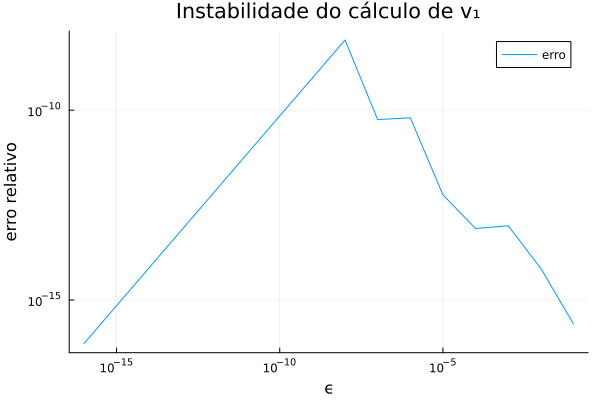

In [8]:
plot_conditioning()

-----------------------------

#### Letra h)